# 分析模块 `src.analysis` 使用示例

演示分析层的 5 个核心函数：

| 函数 | 需要 PyBaMM `sol` | 说明 |
| --- | --- | --- |
| `calc_rrmse` | × | 任意两条曲线的 RMSE / 相对 RMSE |
| `get_discharge_capacity` | √ | 每圈放电容量（Ah） |
| `compute_cycle_energies` / `extract_all_metrics_from_sol` | √ | 每圈充放电容量、能量、能效 |
| `get_all_heat_components` | √ | 每圈充放电的不可逆/可逆/总产热 |
| `calculate_cycle_swelling` | √ | 每圈最大/最小膨胀力 |

为了让这些 `sol` 函数能跑，本 notebook 会先跑一个**最小 PyBaMM 仿真**（2 圈 0.5C，约 30s）。

In [ ]:
# --- BatteryProject 路径自动定位 (无论从 root 还是 examples/ 启动 notebook 都能工作) ---
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
for _cand in (_HERE, *_HERE.parents):
    if (_cand / "src" / "easy_imports.py").exists() and (_cand / "pyproject.toml").exists():
        _ROOT = _cand
        break
else:
    raise RuntimeError(f"Cannot locate BatteryProject root from {_HERE}")
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("BatteryProject root:", _ROOT)

In [ ]:
from src.easy_imports import *
from src.analysis import (
    calc_rrmse,
    get_discharge_capacity,
    compute_cycle_energies,
    extract_all_metrics_from_sol,
    get_all_heat_components,
    calculate_cycle_swelling,
)

import numpy as np
import matplotlib.pyplot as plt
import pybamm

## 1. `calc_rrmse` — 不依赖仿真的纯指标函数

返回 `(rmse, rrmse)`，其中 `rrmse = rmse / mean(y_true)`。
适合任何 sim vs exp 对比场景。

In [ ]:
rng = np.random.default_rng(0)
y_true = np.linspace(1.0, 0.85, 50)
y_pred_good = y_true + rng.normal(0, 0.003, y_true.size)
y_pred_bad  = y_true + rng.normal(0, 0.02,  y_true.size) - 0.01

print(f"good model: rmse={calc_rrmse(y_true, y_pred_good)[0]:.4f}  rrmse={calc_rrmse(y_true, y_pred_good)[1]:.4f}")
print(f"bad  model: rmse={calc_rrmse(y_true, y_pred_bad)[0]:.4f}  rrmse={calc_rrmse(y_true, y_pred_bad)[1]:.4f}")

## 2. 跑一个最小 PyBaMM 仿真

用基础 DFN + Hithium 参数集 + 2 圈 0.5C 充放，得到 `sol`。
**不启用**老化（SEI/plating/LAM）以保持轻量；老化版见 `examples/aging_identification_demo.py`。

In [ ]:
model = pybamm.lithium_ion.DFN()

param = pybamm.ParameterValues("OKane2022")
param.update(get_hithium_params(t_factor=1, temperature=298.15), check_already_exists=False)
param.update({
    "Initial hysteresis state in negative electrode": 0.0,
    "Initial hysteresis state in positive electrode": 0.0,
}, check_already_exists=False)

experiment = pybamm.Experiment([
    ("Discharge at 0.5C until 2.5 V",
     "Rest for 5 minutes",
     "Charge at 0.5C until 3.65 V",
     "Hold at 3.65 V until 0.05C",
     "Rest for 5 minutes")
] * 2)

solver = pybamm.IDAKLUSolver(rtol=1e-6, atol=1e-6)
var_pts = {"x_n": 5, "x_s": 5, "x_p": 5, "r_n": 10, "r_p": 10}

sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment, solver=solver, var_pts=var_pts)
sol = sim.solve(calc_esoh=False)
print("仿真完成；圈数 =", len(sol.cycles))

## 3. `get_discharge_capacity` — 每圈放电容量

In [ ]:
caps = get_discharge_capacity(sol)
print("discharge_capacity (Ah):", caps["discharge_capacity"].round(3))

## 4. `compute_cycle_energies` / `extract_all_metrics_from_sol`

前者返回 dict（推荐），后者返回 4-tuple（兼容旧代码）。

In [ ]:
res = compute_cycle_energies(sol)
for k, v in res.items():
    print(f"{k:18s}: {np.asarray(v).round(3)}")

In [ ]:
# 旧风格 4-tuple
cap, e_chg, e_dchg, eff = extract_all_metrics_from_sol(sol)
print("放电容量 :", cap.round(3))
print("充电能量 :", e_chg.round(3))
print("放电能量 :", e_dchg.round(3))
print("能效     :", eff.round(4))

## 5. `get_all_heat_components` — 每圈产热功率分量

返回 6 个数组（`irrev_chg / irrev_dchg / rev_chg / rev_dchg / total_chg / total_dchg`），
单位都是 W（步内时间平均，按充/放电分别拼接）。

**温度从 label_for_temp 字符串解析**（例如 `"25°C"` → 298.15 K），用于计算可逆热 `I*T*dU/dT`。

In [ ]:
heat = get_all_heat_components(sol, label_for_temp="25°C 0.5P")
for k, v in heat.items():
    print(f"{k:12s}: {np.asarray(v).round(3)}  W")

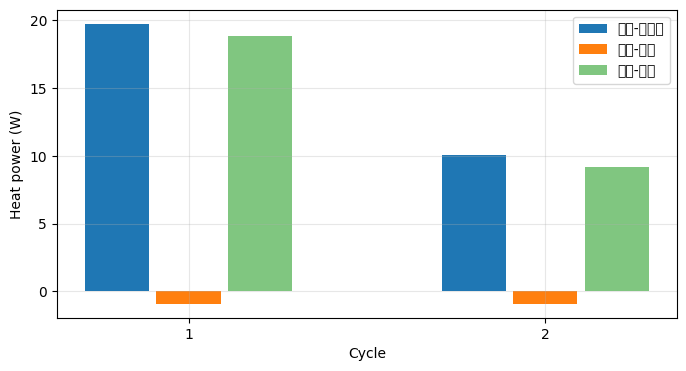

In [ ]:
# 简单可视化：充放电的不可逆/可逆/总产热
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, len(heat["total_dchg"]) + 1)
ax.bar(x - 0.2, heat["irrev_dchg"], width=0.18, label="放电-不可逆")
ax.bar(x,       heat["rev_dchg"],   width=0.18, label="放电-可逆")
ax.bar(x + 0.2, heat["total_dchg"], width=0.18, label="放电-总热", alpha=0.6)
ax.set_xlabel("Cycle"); ax.set_ylabel("Heat power (W)"); ax.set_xticks(x)
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 6. `calculate_cycle_swelling` — 每圈膨胀力

**简化模型**：体积位移 = 浓度引起的可逆项 + SEI 厚度（不可逆项），再乘 `k_stiffness` + 加 `preload_force`。

- 默认 `omega_p=0`、`omega_n=0.1 * 3.1e-6`，**只算负极**膨胀；正极如要参与需自行调 `omega_p`。
- 当前 sol 没启用 SEI，所以**不可逆项 = 0**，只展示可逆膨胀振幅。

In [ ]:
max_f, min_f = calculate_cycle_swelling(sol, param, k_stiffness=1.0e9, preload_force=300.0)
print("每圈最大膨胀力 (N):", max_f.round(1))
print("每圈最小膨胀力 (N):", min_f.round(1))

# 完整分解：(max, min, end-of-cycle baseline, reversible amplitude)
mx, mn, eoc, amp = calculate_cycle_swelling(sol, param, return_components=True)
print("\n圈末基线力     :", eoc.round(1))
print("可逆摆幅       :", amp.round(1))

## 7. 把 sim 指标喂回 `BatteryPlotter` 做可视化

演示与 `plotting` 模块的协作 —— 同样的指标可以叠加多个 sol（不同温度/倍率）做对比。

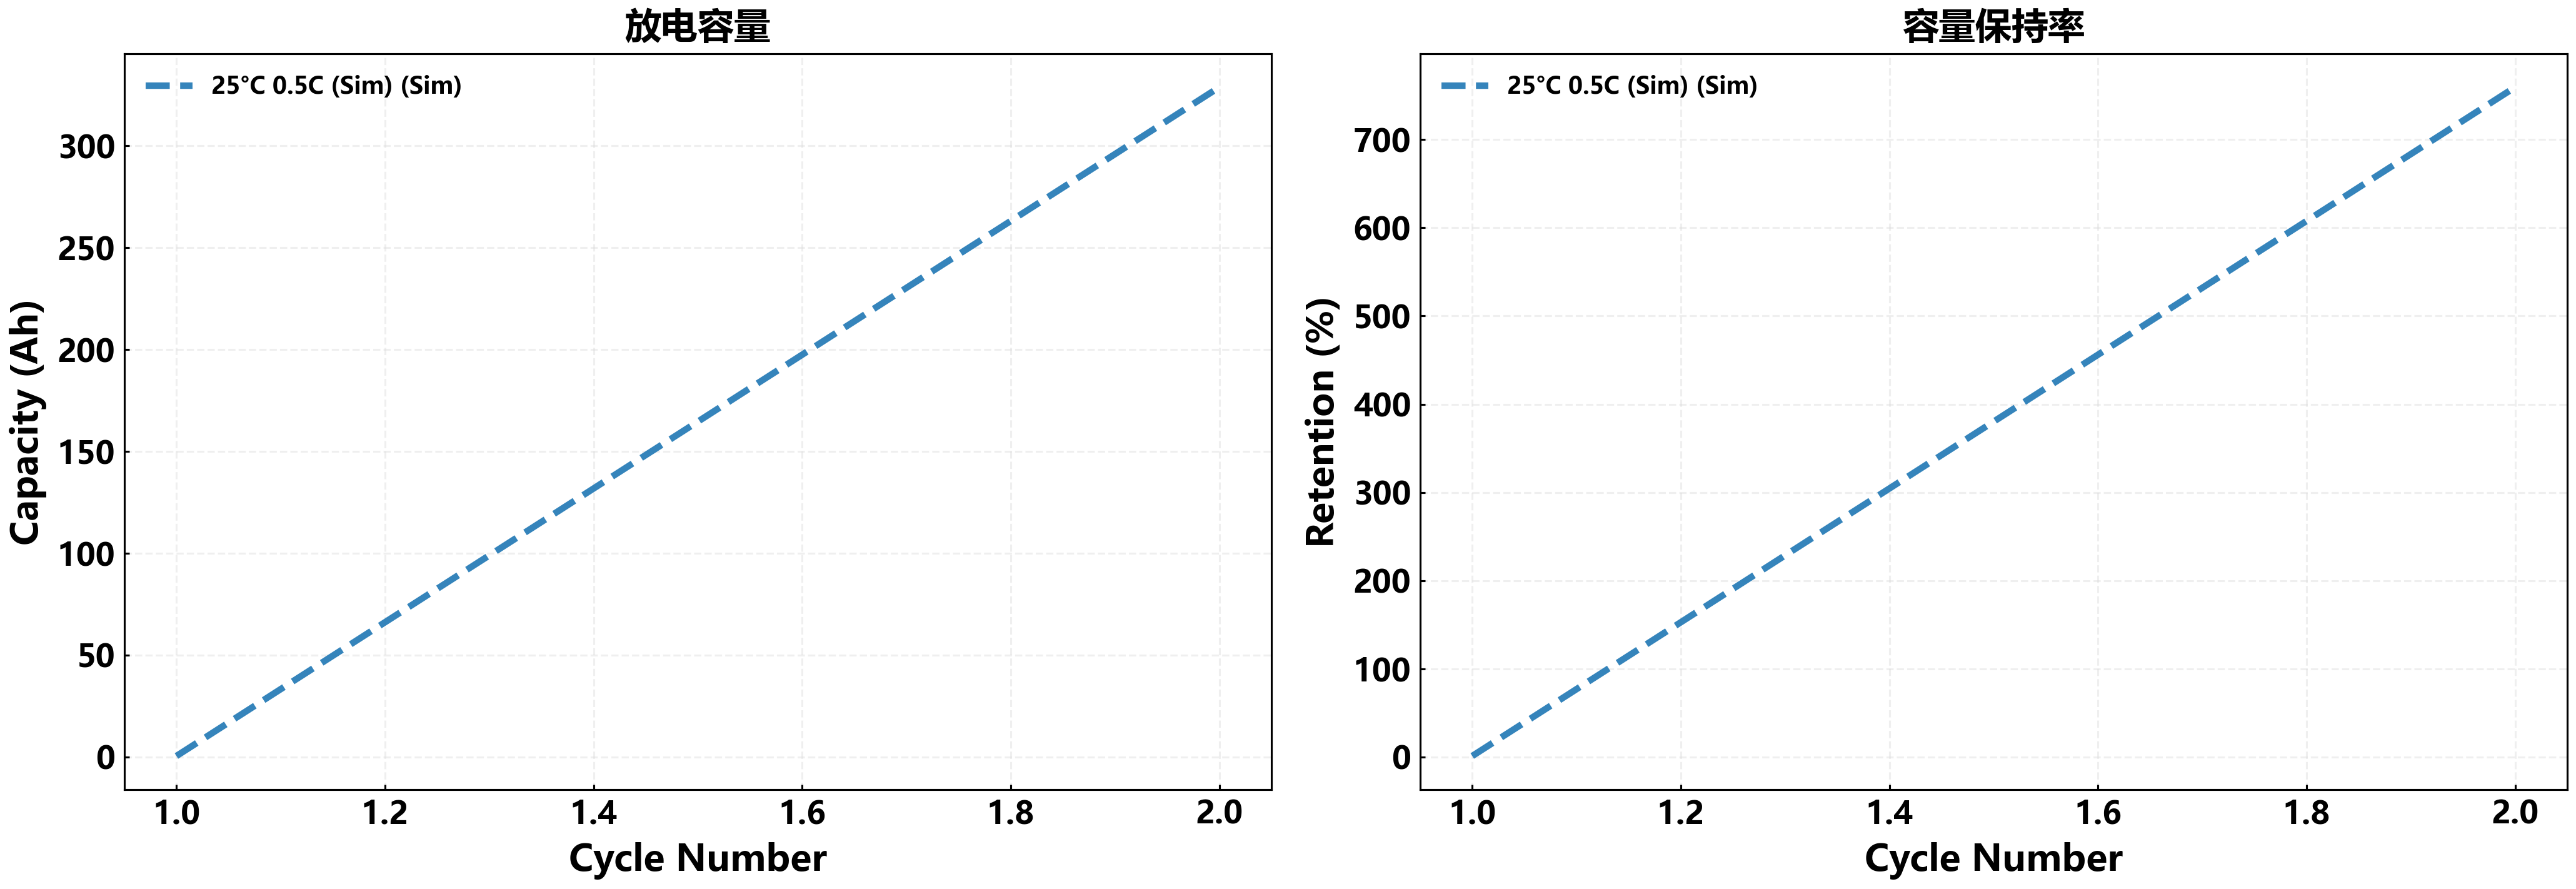

In [ ]:
plotter = BatteryPlotter()
cycle_idx = np.arange(1, len(cap) + 1)
retention = cap / cap[0]
plotter.add_sim_data("25°C 0.5C (Sim)", cycle_idx, capacity=cap, retention=retention)
plotter.plot(target_sim="all", ylabel_left="Capacity (Ah)")
plt.show()

## 备注

- 老化（容量衰减、SEI 厚度）需要启用模型选项 `SEI`/`lithium plating`/`loss of active material`；
  全套老化拟合见 [aging_identification_demo.py](aging_identification_demo.py)。
- 仿真-实验一站式对标见 [compare_demo.ipynb](compare_demo.ipynb)。